In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("open_units.csv")

df.head()

,index,Product,Brand,Category,Style,Quantity,Quantity Units,Volume,Package,ABV,Units of Alcohol,Units (4 Decimal Places),Units per 100ml
0,0,13 Guns,Crafty Dan,Beer,IPA,330,ml,330,bottle,5.5,1.8,1.815,0.55
1,1,13 Guns,Crafty Dan,Beer,IPA,330,ml,330,can,5.5,1.8,1.815,0.55
2,2,13 Guns,Crafty Dan,Beer,IPA,1,pint,568,draught,5.5,3.1,3.124,0.55
3,3,Abbot Ale,Greene King,Beer,Ale,500,ml,500,bottle,5.0,2.5,2.500,0.50
4,4,Abbot Ale,Greene King,Beer,Beer,1,pint,568,draught,5.0,2.8,2.840,0.50


In [3]:
print(df.shape)
print(df.info())
print(df.describe())

# Check missing values
print(df.isnull().sum())

(1082, 13)
<class 'pandas.DataFrame'>
RangeIndex: 1082 entries, 0 to 1081
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   index                     1082 non-null   int64  
 1   Product                   1082 non-null   str    
 2   Brand                     1082 non-null   str    
 3   Category                  1082 non-null   str    
 4   Style                     931 non-null    str    
 5   Quantity                  1082 non-null   int64  
 6   Quantity Units            1082 non-null   str    
 7   Volume                    1082 non-null   int64  
 8   Package                   1082 non-null   str    
 9   ABV                       1082 non-null   float64
 10  Units of Alcohol          1082 non-null   float64
 11  Units (4 Decimal Places)  1082 non-null   float64
 12  Units per 100ml           1082 non-null   float64
dtypes: float64(4), int64(3), str(6)
memory usage: 160.7 KB
None
   

In [4]:
df = df.dropna()   # or you can use fillna if needed

In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load sample dataset
data = load_iris()
X = data.data
y = data.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Split successful")

Split successful


In [7]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_preds))
print(classification_report(y_test, dt_preds))


Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [8]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [9]:
print("Decision Tree Confusion Matrix")
print(confusion_matrix(y_test, dt_preds))

print("\nRandom Forest Confusion Matrix")
print(confusion_matrix(y_test, rf_preds))

Decision Tree Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Random Forest Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


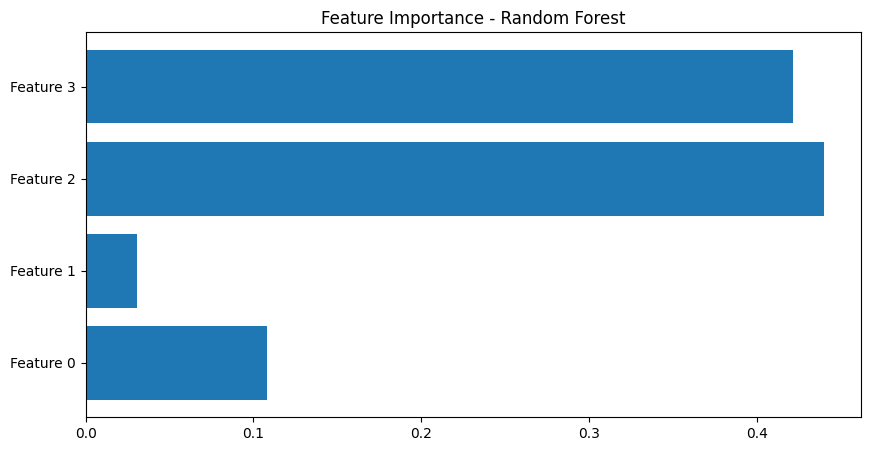

In [11]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = [f"Feature {i}" for i in range(X.shape[1])]  # or use real names

plt.figure(figsize=(10,5))
plt.barh(features, importances)
plt.title("Feature Importance - Random Forest")
plt.show()